In [1]:
# import modules
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

np.set_printoptions(suppress=True)

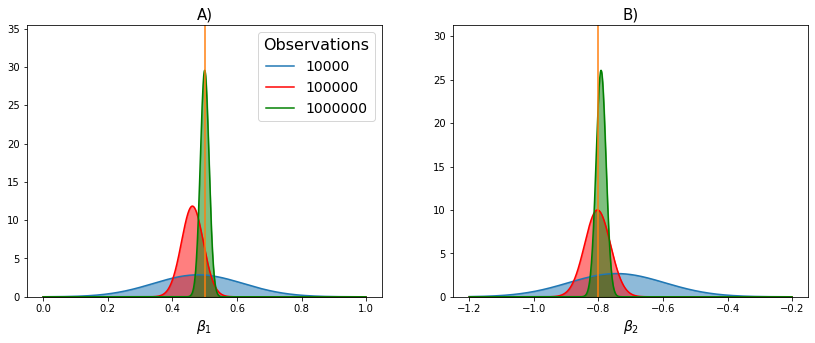

In [19]:
# Plotting probability density of 10000,100000,1000000
x = np.arange(0,1.0,0.001)
K= tfp.distributions.Normal(loc=0.480,scale=0.139).prob(x)
L = tfp.distributions.Normal(loc=0.462,scale=0.0337).prob(x)
M = tfp.distributions.Normal(loc=0.500,scale=0.0135).prob(x)

fig,ax=plt.subplots(1,2, figsize=(14,5))
ax[0].plot(x,K,c='C0')
ax[0].plot(x,L,c='red')
ax[0].plot(x,M,c='green')
ax[0].fill_between(x,K,color='C0',alpha=0.5)
ax[0].fill_between(x,L,color='red',alpha=0.5)
ax[0].fill_between(x,M,color='green',alpha=0.5)
ax[0].axvline(0.5,c='C1')
ax[0].set_ylim(0,M.numpy().max()*1.2)
ax[0].set_xlabel(r"$\beta_1$",fontsize=14)
ax[0].set_title("A)",fontsize=15)
ax[0].legend(loc="upper right",labels=["10000","100000","1000000"],title="Observations",
             fontsize=14,title_fontsize=16)

x = np.arange(-1.2,-0.2,0.001)
K1= tfp.distributions.Normal(loc=-0.744,scale=0.149).prob(x)
L1= tfp.distributions.Normal(loc=-0.803,scale=0.0399).prob(x)
M1= tfp.distributions.Normal(loc=-0.792,scale=0.0153).prob(x)

ax[1].plot(x,K1,c='C0')
ax[1].plot(x,L1,c='red')
ax[1].plot(x,M1,c='green')
ax[1].fill_between(x,K1,color='C0',alpha=0.5)
ax[1].fill_between(x,L1,color='red',alpha=0.5)
ax[1].fill_between(x,M1,color='green',alpha=0.5)
ax[1].axvline(-0.8,c='C1')
ax[1].set_ylim(0,M1.numpy().max()*1.2)
ax[1].set_xlabel(r"$\beta_2$", fontsize=14)
ax[1].set_title("B)",fontsize=15)

plt.savefig('Figure2.png')
plt.show()

In [5]:
# Load data
dat=pd.read_csv("Z_score.csv")
dat.head()


,Coef,Observation,beta_1,beta_2,mean1,mean2,sd1,sd2,Z_value,Z_score,Rank,Percentiles,Theoretical_Z,Sample_Z
37,PN,100000,0.5,-0.8,0.513850,-0.552522,0.035690,0.041581,Z2,-5.951650,1,0.002083,-2.865260,-3.834112
81,PP,100000,1.2,1.8,1.210825,2.002243,0.037095,0.044150,Z2,-4.580819,2,0.006250,-2.497705,-2.936079
154,NP,100000,-1.5,1.8,-1.343098,1.757044,0.035588,0.042407,Z1,-4.408829,3,0.010417,-2.310991,-2.823407
159,NP,100000,-1.5,1.8,-1.379314,1.945967,0.039598,0.043100,Z2,-3.386695,4,0.014583,-2.181227,-2.153806
148,NP,100000,-1.5,1.8,-1.367607,1.727106,0.039720,0.042281,Z1,-3.333127,5,0.018750,-2.080278,-2.118714


In [4]:
# Sort the values
dat=dat.sort_values(by=["Z_score"])

#Rank from the lowest to highest
dat["Rank"]=np.arange(1,241,1)

# Calculate the percentiles
dat["Percentiles"]=(dat["Rank"]-0.5)/240

# Calculate theoretical quantiles
dat["Theoretical_Z"]=stats.norm.ppf(dat["Percentiles"])

# Calculate Sample quantiles
dat["Sample_Z"]=(dat["Z_score"]-np.mean(dat["Z_score"]))/np.std(dat["Z_score"])

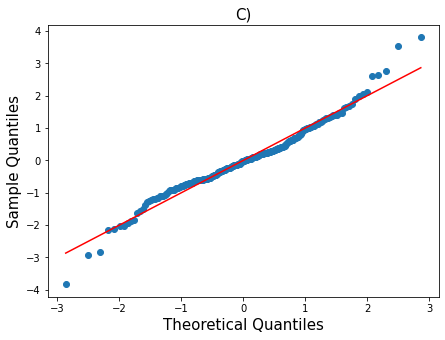

In [23]:
# Plotting QQ-plot
fig=plt.figure(figsize=(7,5))
plt.plot(dat["Theoretical_Z"],dat["Sample_Z"],"o")
plt.plot(dat["Theoretical_Z"],dat["Theoretical_Z"]*1 + 0,color="r")
plt.xlabel("Theoretical Quantiles",fontsize=15)
plt.ylabel("Sample Quantiles",fontsize=15)
plt.title("C)",fontsize=15)
plt.savefig("QQ-plot.png")
plt.show()